# Informe individual del rating Elo

Este notebook carga `elo_v1_output/final_ratings.csv` y genera, para un `athlete_id`:

- un radar con los cuatro Elo: super sprint, sprint, fondo y maratón;
- evidencia directa y efectiva por distancia;
- incertidumbre operativa del motor, $U=\lambda/(\lambda+n_{effective})$;
- modificadores de disciplina y embarcación;
- contextos principales y recuentos de carreras.

> La incertidumbre mostrada controla cuánto aprende el Elo. No es un intervalo de confianza estadístico.

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)

LENGTHS = ['super_sprint', 'sprint', 'fondo', 'maraton']
LENGTH_LABELS = ['Super sprint', 'Sprint', 'Fondo', 'Maratón']
PRIMARY_LAMBDA = 10.0
MODIFIER_LAMBDA = 5.0
BASE_ELO = 1500.0
# Supuesto visual: uncertainty U=1 -> banda de +/-200 Elo; U=0 -> +/-0 Elo.
UNCERTAINTY_ELO_SPAN = 500.0
COLORS = ['#176B87', '#2E8B57', '#D08A37', '#9A4D8F']

In [7]:
# Funciona tanto al ejecutar el notebook desde la raíz como desde elo/.
csv_candidates = [
    Path('elo_v1_output/final_ratings.csv'),
    Path('elo/elo_v1_output/final_ratings.csv'),
]
CSV_PATH = next((path for path in csv_candidates if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError('No se encontró elo_v1_output/final_ratings.csv')

ratings = pd.read_csv(CSV_PATH, dtype={'athlete_id': 'string'})
ratings['athlete_id'] = ratings['athlete_id'].str.strip()

print(f'CSV: {CSV_PATH.resolve()}')
print(f'Deportistas disponibles: {len(ratings):,}')
display(ratings.head(3))

CSV: /home/asier/personal/athlete_ranker/elo/elo_v1_output/final_ratings.csv
Deportistas disponibles: 20,211


,athlete_id,primary_tipo,primary_boat,last_seen,super_sprint_elo,super_sprint_n_direct,super_sprint_n_effective,sprint_elo,sprint_n_direct,sprint_n_effective,...,maraton_elo,maraton_n_direct,maraton_n_effective,tipo_modifiers_json,boat_modifiers_json,context_length_ratings_json,tipo_race_counts_json,boat_race_counts_json,tipo_effective_counts_json,boat_effective_counts_json
0,1000,aguas_tranquilas,kayak,2017-05-01,1519.083551,0,1.097487,1556.484835,0,3.207107,...,1593.578504,6,8.194544,"{""mar"": {""modifier"": -7.0653264820146795, ""n_direct"": 4, ""n_effective"": 4.0}}",{},{},"{""aguas_tranquilas"": 6, ""mar"": 4}","{""kayak"": 10}","{""aguas_tranquilas"": 5.121320343559642, ""mar"": 4.0}","{""kayak"": 9.121320343559642}"
1,10000,aguas_tranquilas,kayak,2022-06-11,1761.099791,0,6.450000,1879.563134,8,9.500000,...,1519.426154,0,3.450000,{},{},{},"{""aguas_tranquilas"": 11}","{""kayak"": 11}","{""aguas_tranquilas"": 11.0}","{""kayak"": 11.0}"
2,10001,aguas_tranquilas,kayak,2022-07-25,1583.225871,0,3.106066,1611.169567,4,4.353553,...,1484.930694,0,1.130330,{},{},{},"{""aguas_tranquilas"": 5}","{""kayak"": 5}","{""aguas_tranquilas"": 4.707106781186548}","{""kayak"": 4.707106781186548}"


In [8]:
def parse_json_cell(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return {}
    if isinstance(value, dict):
        return value
    text = str(value).strip()
    return json.loads(text) if text else {}


def uncertainty(n_effective, lambda_):
    n = max(0.0, float(n_effective or 0.0))
    return float(lambda_) / (float(lambda_) + n)


def get_athlete_row(athlete_id, dataframe=ratings):
    athlete_id = str(athlete_id).strip()
    matches = dataframe.loc[dataframe['athlete_id'] == athlete_id]
    if matches.empty:
        prefix = dataframe.loc[dataframe['athlete_id'].str.startswith(athlete_id), 'athlete_id'].head(10).tolist()
        suggestion = f' IDs que empiezan igual: {prefix}' if prefix else ''
        raise KeyError(f'No existe athlete_id={athlete_id!r}.{suggestion}')
    if len(matches) > 1:
        raise ValueError(f'El athlete_id={athlete_id!r} aparece {len(matches)} veces')
    return matches.iloc[0]


def build_length_table(row):
    records = []
    for key, label in zip(LENGTHS, LENGTH_LABELS):
        n_effective = float(row[f'{key}_n_effective'])
        u = uncertainty(n_effective, PRIMARY_LAMBDA)
        records.append({
            'distancia': label,
            'elo': float(row[f'{key}_elo']),
            'n_direct': int(row[f'{key}_n_direct']),
            'n_effective': n_effective,
            'uncertainty': u,
            'confidence_indicator': 1.0 - u,
        })
    return pd.DataFrame(records).set_index('distancia')


def build_modifier_table(row):
    records = []
    sources = [
        ('Disciplina', 'tipo_modifiers_json'),
        ('Embarcación', 'boat_modifiers_json'),
    ]
    for kind, column in sources:
        for context, values in parse_json_cell(row[column]).items():
            n_effective = float(values.get('n_effective', 0.0))
            u = uncertainty(n_effective, MODIFIER_LAMBDA)
            records.append({
                'tipo': kind,
                'contexto': context,
                'modifier': float(values.get('modifier', values.get('raw_modifier', 0.0))),
                'n_direct': int(values.get('n_direct', 0)),
                'n_effective': n_effective,
                'uncertainty': u,
                'confidence_indicator': 1.0 - u,
            })
    columns = ['tipo', 'contexto', 'modifier', 'n_direct', 'n_effective', 'uncertainty', 'confidence_indicator']
    return pd.DataFrame(records, columns=columns)


def build_context_counts(row):
    records = []
    for kind, column in [('Disciplina', 'tipo_race_counts_json'), ('Embarcación', 'boat_race_counts_json')]:
        for context, count in parse_json_cell(row[column]).items():
            records.append({'tipo': kind, 'contexto': context, 'carreras': int(count)})
    return pd.DataFrame(records, columns=['tipo', 'contexto', 'carreras'])

In [9]:
def plot_athlete_dashboard(row, length_table, modifier_table, context_counts):
    fig = plt.figure(figsize=(16, 9), constrained_layout=True)
    grid = fig.add_gridspec(2, 3, width_ratios=[1.35, 1, 1])

    # Radar de los cuatro Elo.
    ax_radar = fig.add_subplot(grid[:, 0], polar=True)
    values = length_table['elo'].to_numpy(dtype=float)
    angles = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    closed_angles = np.r_[angles, angles[0]]
    uncertainty_values = length_table['uncertainty'].to_numpy(dtype=float)
    uncertainty_width = UNCERTAINTY_ELO_SPAN * uncertainty_values
    lower_values = values - uncertainty_width
    upper_values = values + uncertainty_width
    closed_values = np.r_[values, values[0]]
    closed_lower = np.r_[lower_values, lower_values[0]]
    closed_upper = np.r_[upper_values, upper_values[0]]
    ax_radar.fill_between(
        closed_angles, closed_lower, closed_upper,
        color='#D08A37', alpha=0.20, label='Banda uncertainty (+/-200 x U)'
    )
    ax_radar.plot(closed_angles, closed_values, color='#176B87', linewidth=2.5, label='Elo estimado')
    ax_radar.fill(closed_angles, closed_values, color='#176B87', alpha=0.14)
    ax_radar.plot(closed_angles, np.repeat(BASE_ELO, len(closed_angles)), '--', color='#D05A37', linewidth=1.5, label='Base 1500')
    ax_radar.scatter(angles, values, s=55, color=COLORS, zorder=3)
    ax_radar.set_xticks(angles, LENGTH_LABELS)
    radial_min = min(BASE_ELO, lower_values.min())
    radial_max = max(BASE_ELO, upper_values.max())
    padding = max(35.0, (radial_max - radial_min) * 0.25)
    ax_radar.set_ylim(radial_min - padding, radial_max + padding)
    ax_radar.set_title('Perfil Elo por distancia', pad=28, fontsize=16, fontweight='bold')
    ax_radar.legend(loc='lower center', bbox_to_anchor=(0.5, -0.12), frameon=False)
    for angle, value, u_value in zip(angles, values, uncertainty_values):
        ax_radar.annotate(
            f'{value:.1f}\nU {u_value:.0%}', (angle, value),
            xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9
        )

    # Evidencia directa y efectiva.
    ax_evidence = fig.add_subplot(grid[0, 1])
    x = np.arange(len(LENGTHS))
    width = 0.36
    ax_evidence.bar(x - width / 2, length_table['n_direct'], width, label='Directa', color='#176B87')
    ax_evidence.bar(x + width / 2, length_table['n_effective'], width, label='Efectiva', color='#83B8C8')
    ax_evidence.set_xticks(x, ['SS', 'S', 'F', 'M'])
    ax_evidence.set_title('Evidencia por distancia')
    ax_evidence.set_ylabel('Número de carreras equivalentes')
    ax_evidence.legend(frameon=False)

    # Incertidumbre y confianza como indicadores complementarios.
    ax_uncertainty = fig.add_subplot(grid[0, 2])
    u_values = length_table['uncertainty'].to_numpy()
    bars = ax_uncertainty.bar(['SS', 'S', 'F', 'M'], u_values, color=COLORS)
    ax_uncertainty.set_ylim(0, 1)
    ax_uncertainty.set_title('Incertidumbre del motor')
    ax_uncertainty.set_ylabel('U = λ / (λ + n efectivo)')
    ax_uncertainty.bar_label(bars, labels=[f'{value:.0%}' for value in u_values], padding=3)

    # Modificadores aprendidos.
    ax_modifiers = fig.add_subplot(grid[1, 1])
    if modifier_table.empty:
        ax_modifiers.axis('off')
        ax_modifiers.text(0.5, 0.55, 'Sin modificadores secundarios', ha='center', va='center', fontsize=13, fontweight='bold')
        ax_modifiers.text(0.5, 0.40, 'Solo aparecen al competir fuera del contexto primario.', ha='center', va='center', fontsize=10, color='#65727d')
    else:
        labels = [f"{kind}: {context}" for kind, context in modifier_table[['tipo', 'contexto']].itertuples(index=False)]
        modifiers = modifier_table['modifier'].to_numpy()
        colors = ['#2E8B57' if value >= 0 else '#C75050' for value in modifiers]
        bars = ax_modifiers.barh(labels, modifiers, color=colors)
        ax_modifiers.axvline(0, color='#152432', linewidth=1)
        ax_modifiers.bar_label(bars, labels=[f'{value:+.1f}' for value in modifiers], padding=3)
        ax_modifiers.set_title('Modificadores de contexto')
        ax_modifiers.set_xlabel('Puntos Elo')

    # Participaciones por contexto.
    ax_counts = fig.add_subplot(grid[1, 2])
    if context_counts.empty:
        ax_counts.axis('off')
        ax_counts.text(0.5, 0.5, 'Sin recuentos de contexto', ha='center', va='center')
    else:
        ordered = context_counts.sort_values('carreras', ascending=True)
        labels = [f"{kind}: {context}" for kind, context in ordered[['tipo', 'contexto']].itertuples(index=False)]
        bars = ax_counts.barh(labels, ordered['carreras'], color='#83B8C8')
        ax_counts.bar_label(bars, padding=3)
        ax_counts.set_title('Participaciones por contexto')
        ax_counts.set_xlabel('Grupos de rendimiento')

    fig.suptitle(
        f"Athlete {row['athlete_id']} · principal: {row['primary_tipo']} / {row['primary_boat']}",
        fontsize=19, fontweight='bold'
    )
    return fig


def athlete_report(athlete_id, dataframe=ratings):
    row = get_athlete_row(athlete_id, dataframe)
    length_table = build_length_table(row)
    modifier_table = build_modifier_table(row)
    context_counts = build_context_counts(row)

    display(Markdown(
        f"## Athlete `{row['athlete_id']}`  \\n"
        f"**Disciplina principal:** `{row['primary_tipo']}` · "
        f"**Embarcación principal:** `{row['primary_boat']}`"
    ))

    display(Markdown('### Ratings, evidencia e incertidumbre'))
    formatted_lengths = length_table.copy()
    formatted_lengths['elo'] = formatted_lengths['elo'].map(lambda value: f'{value:.1f}')
    formatted_lengths['n_effective'] = formatted_lengths['n_effective'].map(lambda value: f'{value:.2f}')
    formatted_lengths['uncertainty'] = formatted_lengths['uncertainty'].map(lambda value: f'{value:.1%}')
    formatted_lengths['confidence_indicator'] = formatted_lengths['confidence_indicator'].map(lambda value: f'{value:.1%}')
    display(formatted_lengths.rename(columns={
        'elo': 'Elo', 'n_direct': 'Evidencia directa', 'n_effective': 'Evidencia efectiva',
        'uncertainty': 'Incertidumbre', 'confidence_indicator': 'Indicador de confianza',
    }))

    display(Markdown('### Modificadores'))
    if modifier_table.empty:
        display(Markdown('_No tiene modificadores secundarios en el CSV._'))
    else:
        formatted_modifiers = modifier_table.copy()
        formatted_modifiers['modifier'] = formatted_modifiers['modifier'].map(lambda value: f'{value:+.1f}')
        formatted_modifiers['n_effective'] = formatted_modifiers['n_effective'].map(lambda value: f'{value:.2f}')
        formatted_modifiers['uncertainty'] = formatted_modifiers['uncertainty'].map(lambda value: f'{value:.1%}')
        formatted_modifiers['confidence_indicator'] = formatted_modifiers['confidence_indicator'].map(lambda value: f'{value:.1%}')
        display(formatted_modifiers.rename(columns={
            'tipo': 'Tipo', 'contexto': 'Contexto', 'modifier': 'Modificador Elo',
            'n_direct': 'Evidencia directa', 'n_effective': 'Evidencia efectiva',
            'uncertainty': 'Incertidumbre', 'confidence_indicator': 'Indicador de confianza',
        }).set_index(['Tipo', 'Contexto']))

    display(Markdown('### Recuentos por contexto'))
    display(context_counts.set_index(['tipo', 'contexto']).rename(columns={'carreras': 'Carreras'}))

    fig = plot_athlete_dashboard(row, length_table, modifier_table, context_counts)
    plt.show()
    return {
        'row': row,
        'lengths': length_table,
        'modifiers': modifier_table,
        'context_counts': context_counts,
        'figure': fig,
    }

## Selecciona el deportista

Cambia únicamente `ATHLETE_ID` y ejecuta esta celda. El ID se trata como texto para conservar cualquier cero inicial.

## Athlete `17199`  \n**Disciplina principal:** `aguas_tranquilas` · **Embarcación principal:** `kayak`

### Ratings, evidencia e incertidumbre

,Elo,Evidencia directa,Evidencia efectiva,Incertidumbre,Indicador de confianza
distancia,,,,,
Super sprint,2835.2,34,41.58,19.4%,80.6%
Sprint,3132.8,20,42.34,19.1%,80.9%
Fondo,3043.1,8,23.85,29.5%,70.5%
Maratón,2504.8,0,11.42,46.7%,53.3%


### Modificadores

_No tiene modificadores secundarios en el CSV._

### Recuentos por contexto

,,Carreras
tipo,contexto,
Disciplina,aguas_tranquilas,62
Embarcación,kayak,62


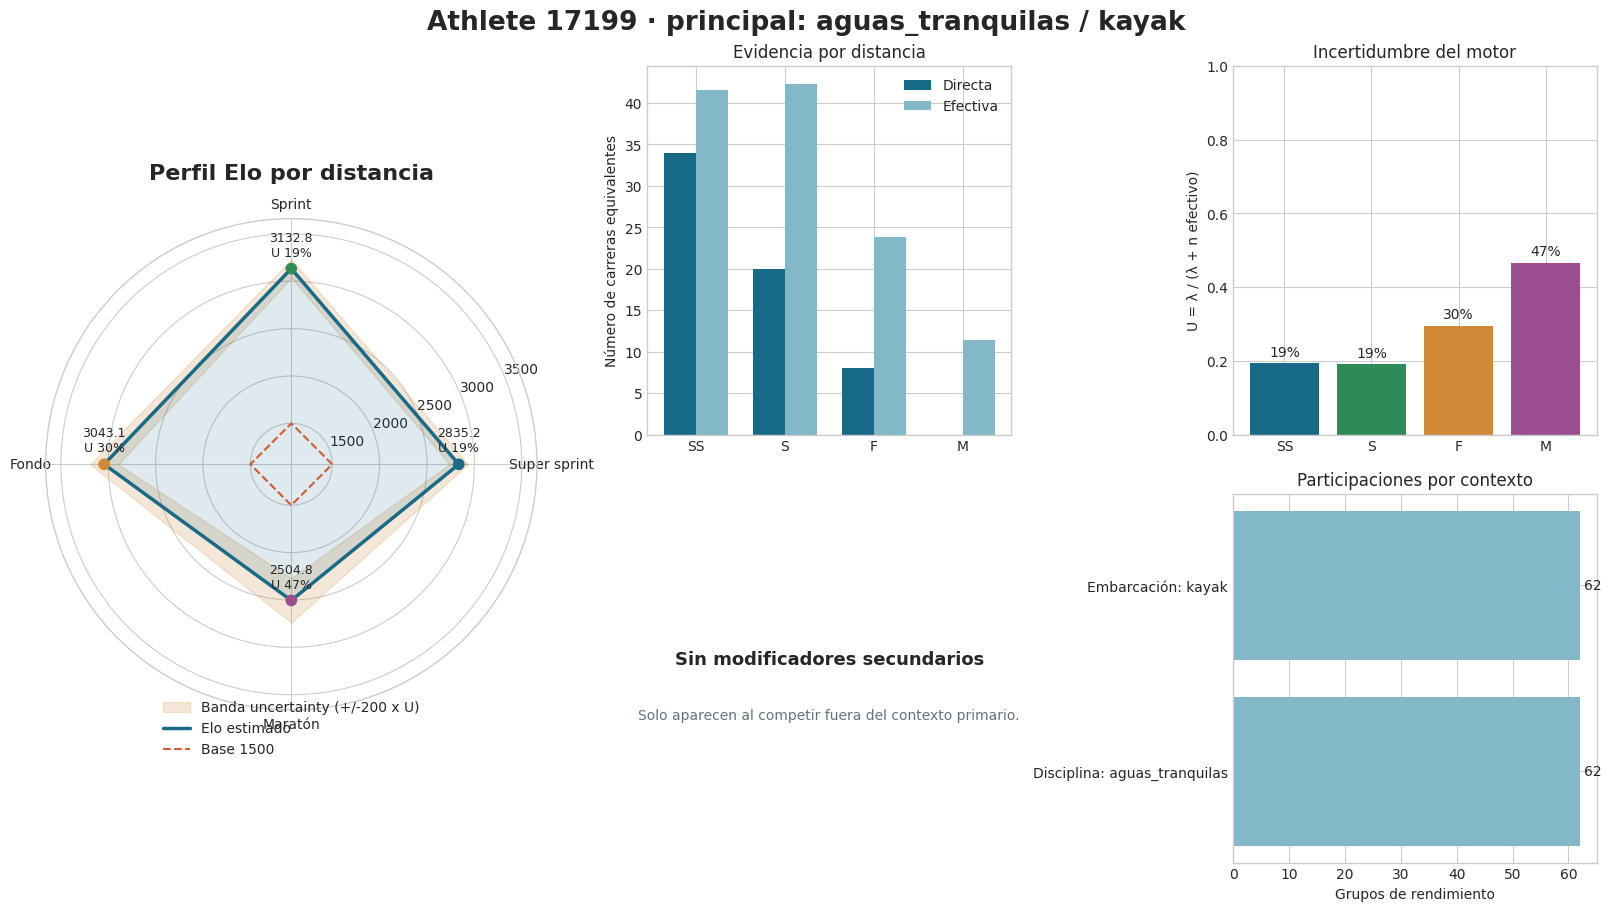

In [14]:
ATHLETE_ID = '17199'

report = athlete_report(ATHLETE_ID)

### Lectura rápida

- **Elo:** nivel estimado para esa distancia. La línea 1500 del radar es el punto inicial del sistema.
- **Evidencia directa:** grupos realmente disputados en esa distancia.
- **Evidencia efectiva:** incluye evidencia transferida desde otras distancias y el ajuste por tamaño de tripulación.
- **Incertidumbre:** alta cuando hay poca evidencia; baja cuando el rating esta asentado. En el radar se representa como una banda heuristica de +/-200 x U puntos Elo.
- **Modificador:** diferencia aprendida respecto al contexto principal del deportista.
- **Indicador de confianza:** `1 - uncertainty`; es descriptivo y no debe presentarse como probabilidad estadística.